# Computational Explorations of the Mandelbrot Set
 
[Moreno Marzolla](https://www.moreno.marzolla.name/), based on code provided by [Michael Marinaccio](https://github.com/mnmarinaccio).

Last modified April 2026.

---

Let us consider the infinite sequence $z_n(c)$ of complex numbers, defined for $n=0, 1, \ldots$ as follows:

\begin{equation}
z_n(c) = \begin{cases}
0 & \mbox{if}\ n = 0\\
z_{n-1}(c)^2 + c & \mbox{otherwise}
\end{cases}
\end{equation}

where $c$ is a complex number. The Mandelbrot set is the set of points $c$ such that the sequence $z_n(c)$ does not diverge for $n \rightarrow \infty$. In the following, the infinite sequence $z_0(c), z_1(c), \ldots$ will be called _Mandelobrot sequence_.

The sequence above can be understood as the orbit of $z=0$ under repeated iteration of function $f_c(z) = z^2 + c$. Let us define a Python function `f(c,z)` that returns $f_c(z)$:

In [40]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import itertools as it
plt.rcParams['figure.dpi'] = 300

def f(c, z):
    return z*z + c

Then, we define a utility function `iterate(f, z0)` that takes as arguments a function `f` of a single parameter, and a starting value `z0`, and generates the infinite sequence $z_0, f(z_0), f^2(z_0), \ldots$.

In [41]:
def iterate(f, z0):
    """
    This function generates the infinite sequence z0, f(z0), f(f(z0)), ...
    """
    while True:
        yield(z0)
        z0 = f(z0)

Now, to make the rest of the code simpler, we define a specialized generator `mandelbrot_it(c)` to enumerate the terms of the Mandelbrot sequence $z_0(c), z_1(c), \ldots$:

In [42]:
def mandelbrot_it(c):
    """
    This function generates the orbit of z=0 under function f(c,z) above.
    """
    return iterate(lambda z : f(c, z), 0+0j)

Finally, we define `mandelbrot_orbit` to generate the first $n$ terms of the sequence $z_0(c), \ldots, z_{n-1}(c)$.

In [43]:
def mandelbrot_orbit(c, n):
    """
    This function returns a list containing the first n points
    of the orbit of c.
    """
    return list(it.islice(mandelbrot_it(c), n))

To test `mandelbrot_orbit()`, let us enumerate the first 10 terms of the Mandelbrot sequence using $c=0$:

In [44]:
mandelbrot_orbit(0, 10)

[0j, 0j, 0j, 0j, 0j, 0j, 0j, 0j, 0j, 0j]

Unsurprisingly, the sequence is made of all zeros, which is indeed the case if we substitute $c=0$ into the equation above. 

Let us try a different value of $c$, say $c=0.3 - 0.2i$:

In [45]:
mandelbrot_orbit(0.3-0.2j, 10)

[0j,
 (0.3-0.2j),
 (0.35-0.32j),
 (0.32009999999999994-0.424j),
 (0.22268800999999996-0.47144479999999994j),
 (0.1273297503507201-0.40997020867369593j),
 (0.1481372933244229-0.3044028086433087j),
 (0.2292835877635513-0.290186816305544j),
 (0.2683625752601786-0.3330701487284355j),
 (0.26108274782629287-0.3787671257101073j)]

In this case the sequence is nonzero; we observe that the magnitude of the terms $z_n(c)$ remains limited, i.e., the first ten terms of the infinite sequence $z_n(c)$ does not diverge (of course, we can not conclude that the whole infinite sequence does not diverge).

Let us try yet another value of $c$, $c = 0.7 + 0.3i$:

In [46]:
mandelbrot_orbit(0.7 + 0.3j, 10)

[0j,
 (0.7+0.3j),
 (1.0999999999999999+0.72j),
 (1.3915999999999997+1.884j),
 (-0.9129054400000005+5.543548799999998j),
 (-29.197536955599826-9.821471712850945j),
 (756.7348576672863+573.8255665886876j),
 (243372.56393789971+868467.9169166809j),
 (-695006317835.1919+422722527275.93896j),
 (3.0433944676427485e+23-5.875896542960736e+23j)]

This time the sequence appears to diverge; indeed, the magnitude (absolute value) of the terms seems to be increasing:

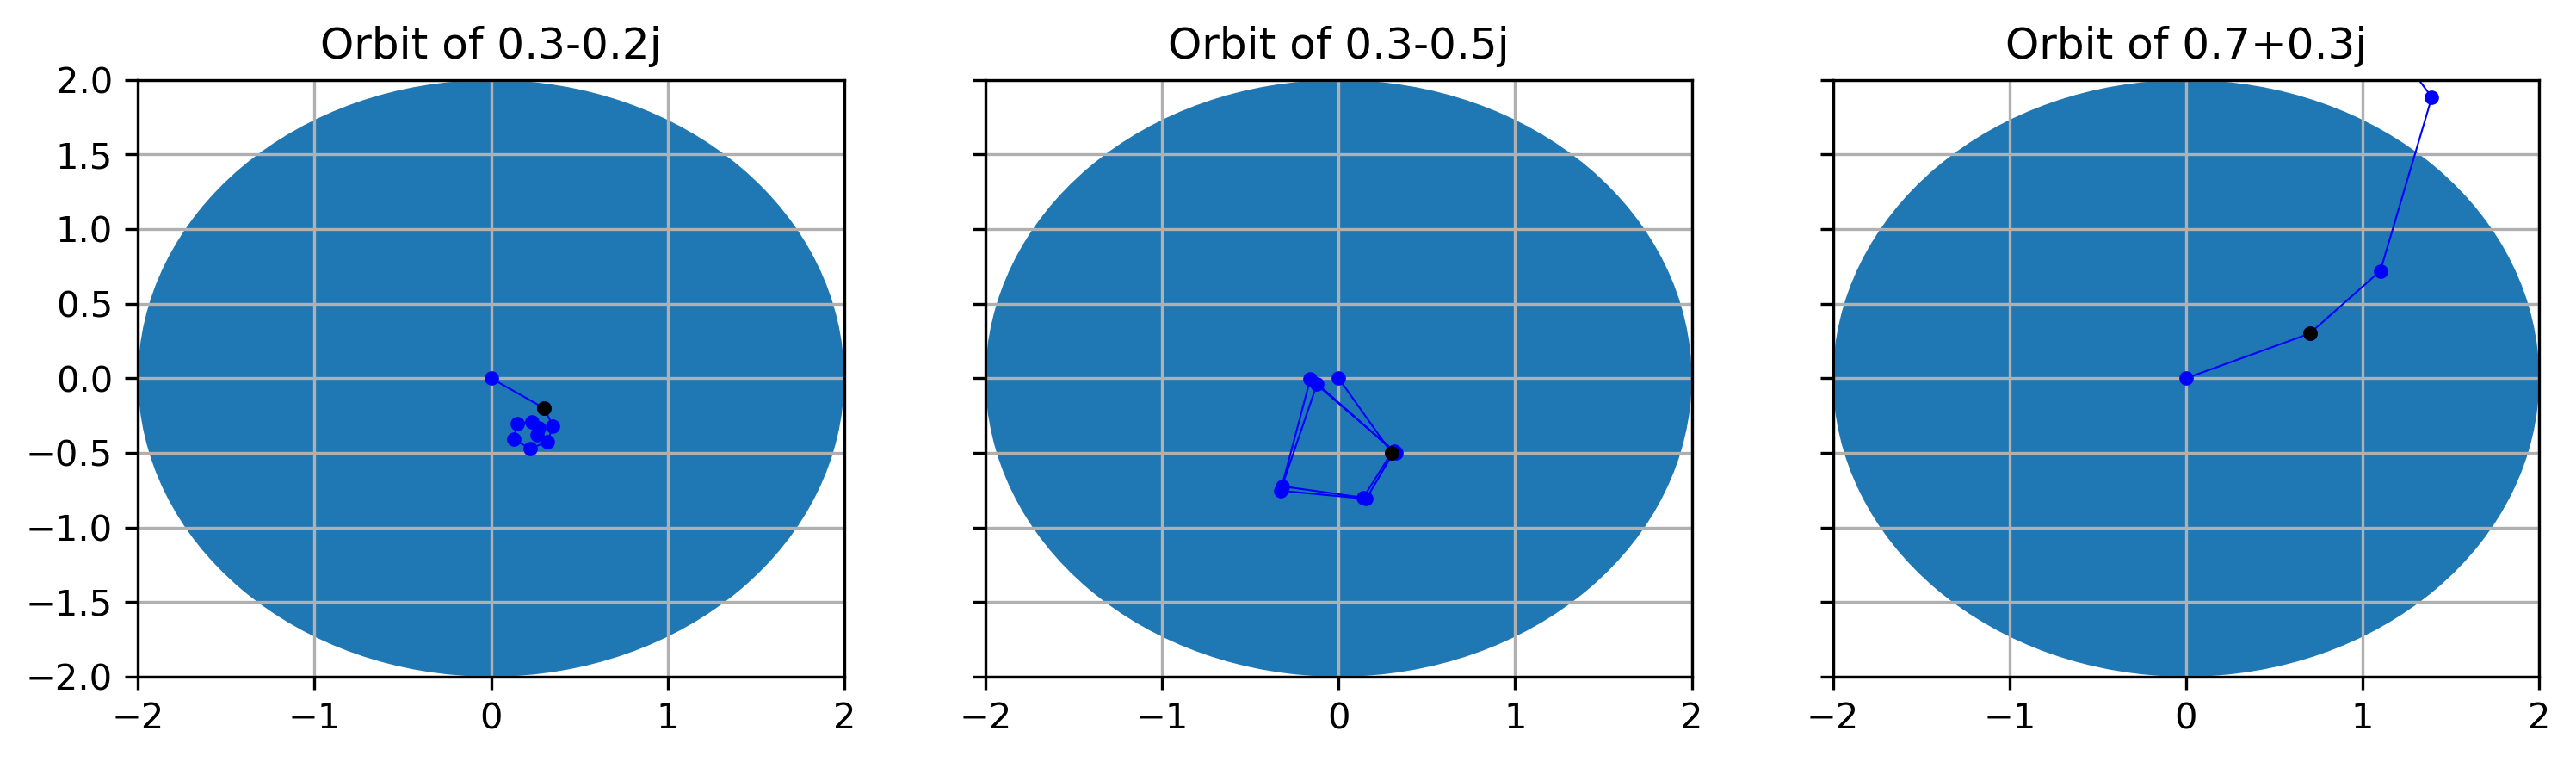

In [47]:
def plot_orbit(z0):
    orb = mandelbrot_orbit(z0, 10)
    draw_circle = plt.Circle((0,0), 2)
    plt.gca().add_artist(draw_circle)
    plt.plot(np.real(orb), np.imag(orb), ".b-", lw=0.5)
    plt.plot(np.real(z0), np.imag(z0), '.k')
    plt.title(f"Orbit of {z0:.1f}")
    plt.grid(True)
    plt.xlim(-2, 2)
    plt.ylim(-2, 2)
    
z0 = 0.2+0.2j
plt.subplots(1,3, figsize=(12,3), sharey=True)
plt.subplot(1,3,1)
plot_orbit(0.3-0.2j)
plt.subplot(1,3,2)
plot_orbit(0.3-0.5j)
plt.subplot(1,3,3)
plot_orbit(0.7 + 0.3j)
plt.show()

It has been proved that the Mandelbrot sequence diverges if there exists a term $|z_k(c)| > 2$. We make use of this observation to draw an approximation of the Mandelbrot set as follows:

- For each $c$ in the complex plane:
  1. Generate up to `maxiter` terms of the sequence;
  2. If we find a term whose absolute value eceeds $2$, then the orbit diverges, and the point $c$ does not belong to the Mandelbrot set.
  3. Otherwise, we assume that the sequence does not diverge, and $c$ belongs to the Mandelbrot set. Note that this assumption might be wrong.
  
Let us define a function `escape_time(c, maxiter)` that generates up to `maxiter` terms of the Mandelbrot sequence; the function returns the first $n$ such that $|z_n(c)| > 2$, or 0 if the first `maxiter` terms do not exceed two in magnitude.

The return value is a quite complex idiomatic Python expression, so it makes sense to try to deconstruct it to see what it does.
- `mandelbrot_it(c)` returns a generator of the Mandelbrot sequence, i.e., a function that enumerates the infinite sequence $z_0(c), z_1(c), \ldots$;
- `it.islice(..., maxiter)` returns the first `maxiter` term of the infinite sequence above;
- `enumerate(...)` returns a list of pairs $(0, z_0(c)), (1, z_1(c), (2, z_2(c)), \ldots$;
- `n,z in ... if abs(z)>2` returns all pairs $(n,z)$ from the sequence above such that the magnitude of $z$ is greater than 2;
- `n for ...` returns only the first element of the list of pairs above, i.e., returns the list of values $n$ such that $|z_n(c)| > 2$, $n < \mathrm{maxiter}$;
- `next(..., 0)` returns the smallest $n$ above, if the list is nonempty (i.e., if the sequence diverges within the first `maxiter` iterations), otherwise 0 (if the sequence does _not_ diverge within the first `maxiter` iterations).

In [48]:
def escape_time(c, maxiter):
    """
    Return the first i such that |z_i(c)| > 2, otherwise maxiter.
    """
    return next((n for n,z in enumerate(it.islice(mandelbrot_it(c), maxiter)) if abs(z) > 2), 0)

Let us test it. The first 10 iterates of $z_n(0.3-0.2i)$ do not diverge, so we get zero:

In [49]:
escape_time(0.3 - 0.2j, 10)

0

On the other hand, $z_3(0.7+0.3i)$ is greater than two:

In [50]:
escape_time(0.7 + 0.3j, 10)

3

Let us define some parameters.

In [51]:
width, height = 800, 600
image_range=[-2, 1, -1.5, 1.5]
maxiter = 100

And finally, we can produce the image of the Mandelbrot set. Technically speaking, this is just an approximation, because:
1. we are considering a discrete mesh of points in the complex plane, whereas the Mandelbrot set is a continuous set of points;
2. we are truncating the infinite sequence $z_n(c)$ to the first `maxiter` terms.

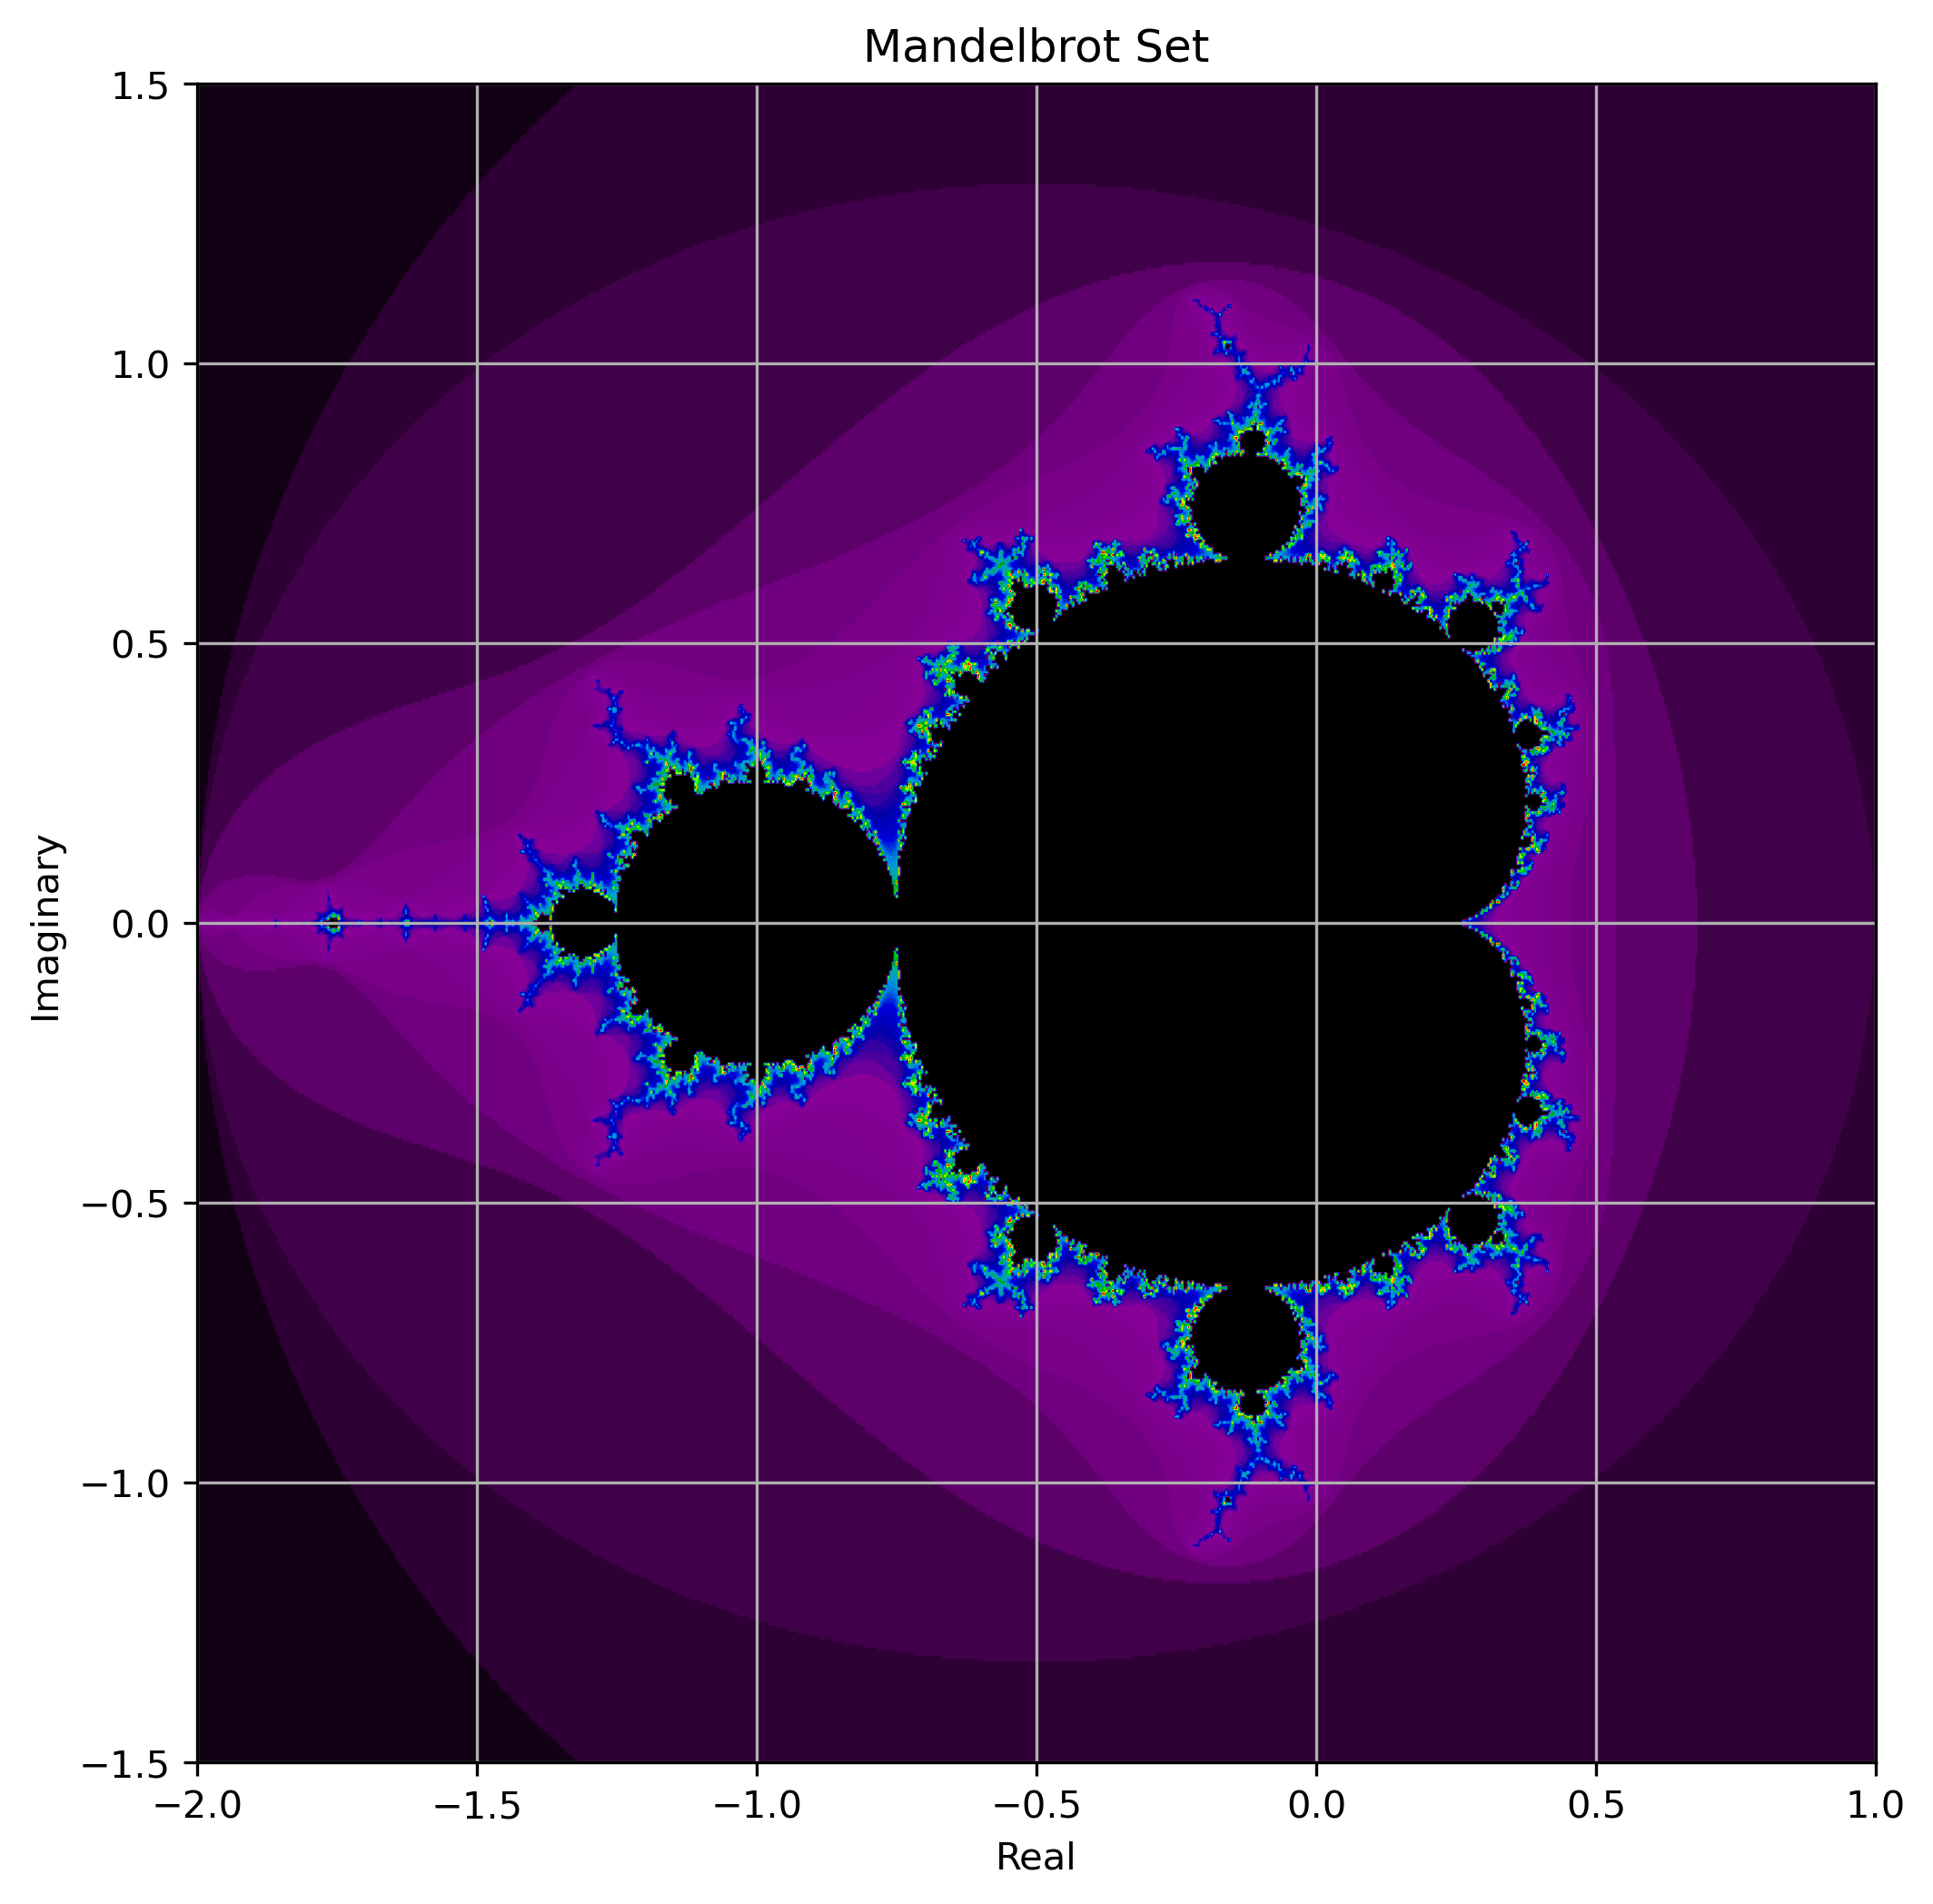

In [53]:
real_range = np.linspace(image_range[0], image_range[1], width)
imag_range = np.linspace(image_range[2], image_range[3], height)

# Create a 2D grid of complex numbers
real, imag = np.meshgrid(real_range, imag_range)
c_vals = real + 1j * imag

escape_times = np.zeros_like(c_vals, dtype=int)

for i in range(c_vals.shape[0]):
    for j in range(c_vals.shape[1]):
        escape_times[i,j] = escape_time(c_vals[i,j], maxiter)
        
# Plot
plt.figure(figsize=(8,8))
plt.imshow(escape_times, extent=image_range, cmap='nipy_spectral', origin='lower')
#plt.colorbar(label='Iterations to Escape')
plt.title('Mandelbrot Set')
plt.xlabel('Real')
plt.ylabel('Imaginary')
plt.grid(True)
#plt.gca().axis("off")
#plt.savefig('mandelbrot-set.png', bbox_inches='tight', pad_inches=0)
plt.show()